# Предсказание стоимости жилья

В проекте вам нужно обучить модель линейной регрессии на данных о жилье в Калифорнии в 1990 году. На основе данных нужно предсказать медианную стоимость дома в жилом массиве. Обучите модель и сделайте предсказания на тестовой выборке. Для оценки качества модели используйте метрики RMSE, MAE и R2.

## 1. Загрузка данных

Объявим необходмые библиотеки, загрузим датафреймы и выведем их основную информацию:

In [1]:
!pip install phik
!pip install shap
!pip install pyspark==3.5.6

In [2]:
import os
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

import pyspark
from pyspark.sql import SparkSession
from pyspark.sql.types import *
import pyspark.sql.functions as F
from pyspark.sql.functions import col as spark_col

from pyspark.ml import Pipeline
from pyspark.ml import PipelineModel
from pyspark.ml.feature import OneHotEncoder
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.feature import StringIndexer
from pyspark.ml.feature import StandardScaler
from pyspark.ml.feature import Imputer
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.stat import Correlation
from pyspark.ml.functions import vector_to_array

from phik import phik_matrix
from phik.report import plot_correlation_matrix

from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.stats.outliers_influence as influence
from statsmodels.tools.tools import add_constant


spark = SparkSession.builder \
                    .master('local') \
                    .appName('EDA California Housing') \
                    .getOrCreate()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/08/11 11:29:12 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
pth_1 = '/datasets/housing.csv'

if os.path.exists(pth_1):
    df = spark.read.load('/datasets/housing.csv', format="csv", sep=",", inferSchema=True, header="true")
    df.printSchema()
    missing_counts = df.select([F.count(F.when(F.isnan(c) | df[c].isNull(), c)).alias(c) for c in df.columns])
    
    df.show(10)
    print('Количество пропусков:')
    missing_counts.show()
    
else:
    print('Путь к первому датафрейму не найден')


root
 |-- longitude: double (nullable = true)
 |-- latitude: double (nullable = true)
 |-- housing_median_age: double (nullable = true)
 |-- total_rooms: double (nullable = true)
 |-- total_bedrooms: double (nullable = true)
 |-- population: double (nullable = true)
 |-- households: double (nullable = true)
 |-- median_income: double (nullable = true)
 |-- median_house_value: double (nullable = true)
 |-- ocean_proximity: string (nullable = true)

+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+---------------+
|longitude|latitude|housing_median_age|total_rooms|total_bedrooms|population|households|median_income|median_house_value|ocean_proximity|
+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+---------------+
|  -122.23|   37.88|              41.0|      880.0|         129.0|     322.0|     126.0|       8.3252|          452600.0|       NEAR B

+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+---------------+
|longitude|latitude|housing_median_age|total_rooms|total_bedrooms|population|households|median_income|median_house_value|ocean_proximity|
+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+---------------+
|        0|       0|                 0|          0|           207|         0|         0|            0|                 0|              0|
+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+---------------+



### Промежуточный вывод:

Данные загружены, соответствуют описанию. Обнаружены пропуски в столбце `total_bedrooms`. Вероятно, при выгрузке данных произошла ошибка, т.к. в остальных столбцах пропусков нет.

## 2. Исследовательский анализ данных и предобработка

### Исследовательский анализ данных 

Изучим параметры датафрейма. Необходимо проверить данные на наличие аномалий и выбросов. Построим гистограммы распределения категориального и количественных признаков. При построении гистограмм ограничимся 90%-ным квантилем для оптимальной визуализации графиков.

+-------+-------------------+
|summary|          longitude|
+-------+-------------------+
|  count|              20640|
|   mean|-119.56970445736148|
| stddev|  2.003531723502584|
|    min|            -124.35|
|    max|            -114.31|
+-------+-------------------+



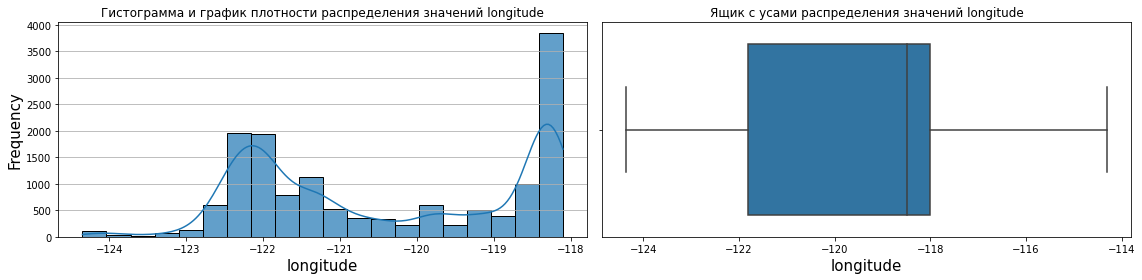

+-------+-----------------+
|summary|         latitude|
+-------+-----------------+
|  count|            20640|
|   mean| 35.6318614341087|
| stddev|2.135952397457101|
|    min|            32.54|
|    max|            41.95|
+-------+-----------------+



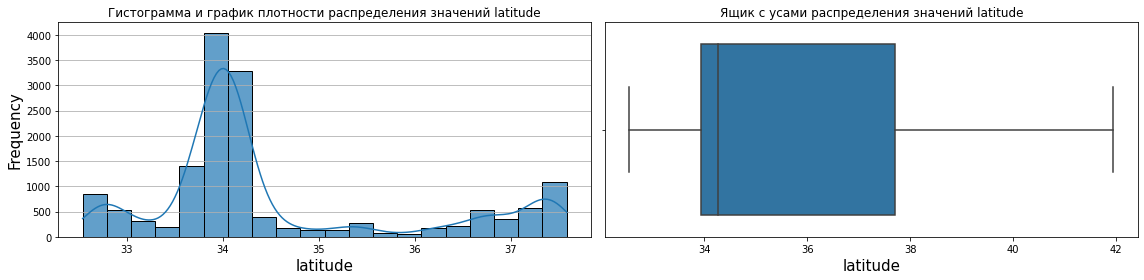

+-------+------------------+
|summary|housing_median_age|
+-------+------------------+
|  count|             20640|
|   mean|28.639486434108527|
| stddev| 12.58555761211163|
|    min|               1.0|
|    max|              52.0|
+-------+------------------+



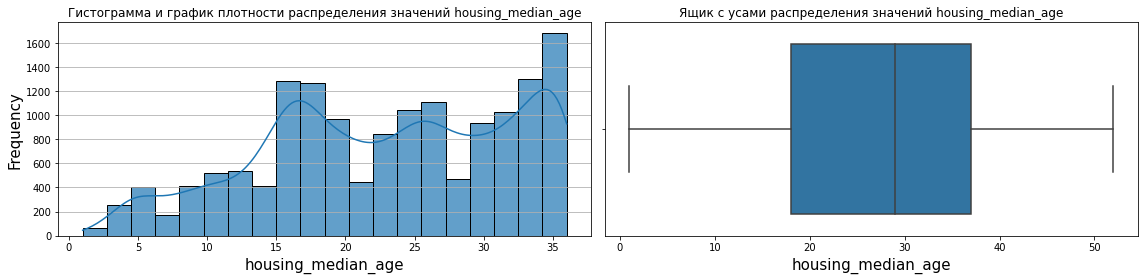

+-------+------------------+
|summary|       total_rooms|
+-------+------------------+
|  count|             20640|
|   mean|2635.7630813953488|
| stddev|2181.6152515827944|
|    min|               2.0|
|    max|           39320.0|
+-------+------------------+



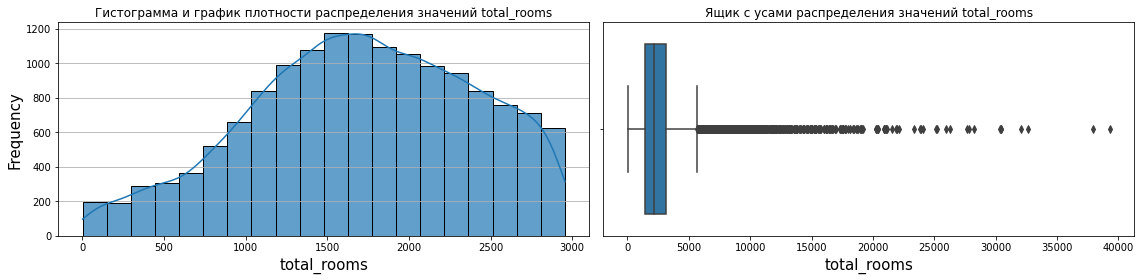

+-------+------------------+
|summary|    total_bedrooms|
+-------+------------------+
|  count|             20433|
|   mean| 537.8705525375618|
| stddev|421.38507007403115|
|    min|               1.0|
|    max|            6445.0|
+-------+------------------+



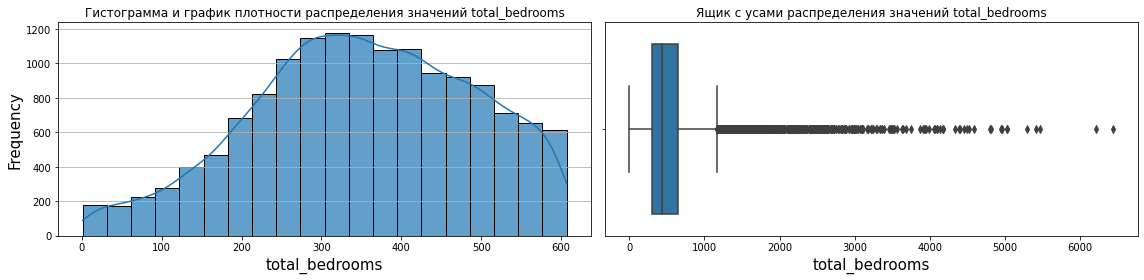

+-------+------------------+
|summary|        population|
+-------+------------------+
|  count|             20640|
|   mean|1425.4767441860465|
| stddev|  1132.46212176534|
|    min|               3.0|
|    max|           35682.0|
+-------+------------------+



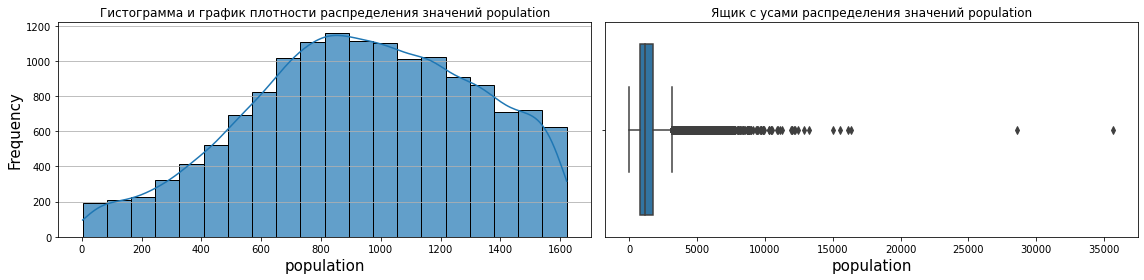

+-------+-----------------+
|summary|       households|
+-------+-----------------+
|  count|            20640|
|   mean|499.5396802325581|
| stddev|382.3297528316098|
|    min|              1.0|
|    max|           6082.0|
+-------+-----------------+



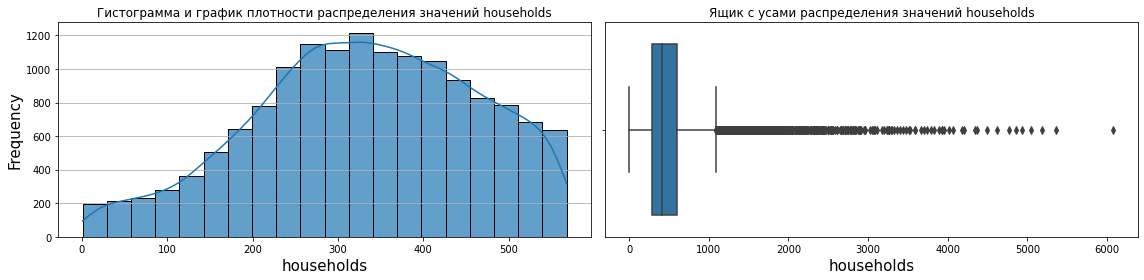

+-------+------------------+
|summary|     median_income|
+-------+------------------+
|  count|             20640|
|   mean|3.8706710029070246|
| stddev| 1.899821717945263|
|    min|            0.4999|
|    max|           15.0001|
+-------+------------------+



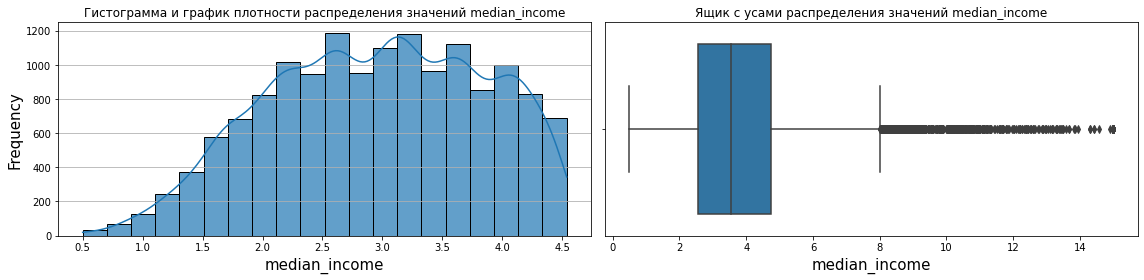

+-------+------------------+
|summary|median_house_value|
+-------+------------------+
|  count|             20640|
|   mean|206855.81690891474|
| stddev|115395.61587441359|
|    min|           14999.0|
|    max|          500001.0|
+-------+------------------+



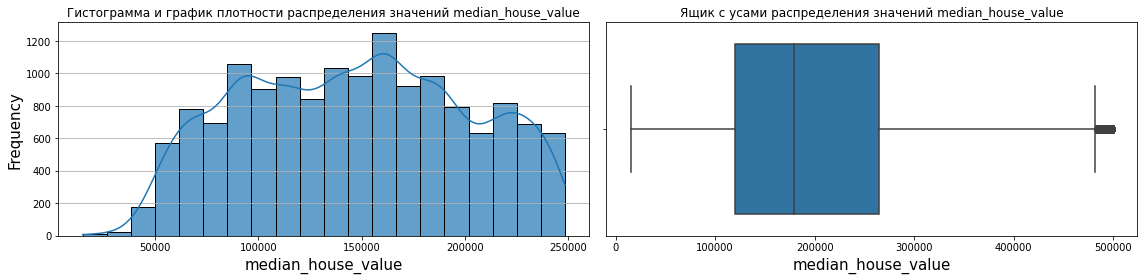

+---------------+-----+
|ocean_proximity|count|
+---------------+-----+
|         ISLAND|    5|
|     NEAR OCEAN| 2658|
|       NEAR BAY| 2290|
|      <1H OCEAN| 9136|
|         INLAND| 6551|
+---------------+-----+



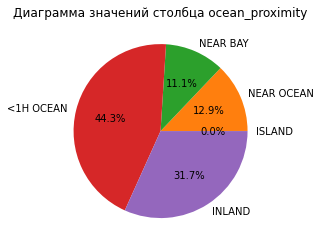

In [4]:
def histogram_spark(data):
    
    '''
        Функция вывода таблицы параметров агрегации, построения графиков распределения значений и ящика с усами
    для каждого столбца с численными данными. В случае, если в данных присутствуют цифровые категориальные значения,
    условием 
    
        distinct_count = data.agg(F.countDistinct(spark_col(col_name))).collect()[0][0]
            if distinct_count > 19: 
    
    можно вычленить данные столбцы и построить для них диаграммы countplot. 
    
        Также есть опциональный цикл для работы с данными формата "datetime".
    
        Для текстовых категориальных столбцов создан отдельный цикл. В нём строятся круговые диаграммы, 
    выводятся уникальные значения и их доля. Не рационален в случае большого количества уникальных значений категорий.
    
        Аргументы:
    data : DataFrame
        Spark DataFrame с числовыми данными.

        Возвращаемое значение:
    None
    
    '''
    
    numeric_cols = [col_name for col_name, col_type in data.dtypes if col_type in ['int', 'bigint', 'float', 'double']]
    text_cols = [col_name for col_name, col_type in data.dtypes if col_type == 'string']
    datetime_cols = [col_name for col_name, col_type in data.dtypes if col_type == 'timestamp']
        
    for col_name in numeric_cols:
        if col_name != 'id':
            distinct_count = data.agg(F.countDistinct(col_name)).collect()[0][0]
            if distinct_count > 19:
                f, ax = plt.subplots(1, 2, figsize=(16, 4))
                
                # Описание данных и вычисление квантилей
                quantiles = [0.25, 0.5, 0.75] 
                data.describe(col_name).show()
                quantile = data.approxQuantile(col_name, [0.25, 0.5, 0.75], 0.05)
                
                # Фильтрация данных для уменьшения выбросов
                filtered_data = data.filter(spark_col(col_name) <= quantile[2])
                
                # Построение графиков
                sns.histplot(x=filtered_data.select(col_name).dropna().rdd.flatMap(lambda x: x).collect(), kde=True, \
             bins=20, multiple='stack', ax=ax[0], alpha=0.7)
                sns.boxplot(x=data.select(col_name).dropna().rdd.flatMap(lambda x: x).collect(), ax=ax[1])
                ax[0].set_title('Гистограмма и график плотности распределения значений {}'.format(col_name))
                ax[0].set_xlabel(col_name, fontsize=15)
                ax[0].set_ylabel('Frequency', fontsize=15)
                ax[0].grid(axis='y')
                ax[1].set_title('Ящик с усами распределения значений {}'.format(col_name))
                ax[1].set_xlabel(col_name, fontsize=15)
                plt.tight_layout()
                plt.show()
            else:
                data.describe(col_name).show()
                sns.countplot(x=data.select(col_name).rdd.flatMap(lambda x: x).collect(), dropna=True)
                plt.grid(axis='y')
                plt.gca().set_axisbelow(True)
                plt.title('Распределение категорий в столбце {}'.format(col))
                plt.tight_layout()
                plt.show()
                
    for col_name in text_cols:
        data.groupBy(col_name).count().show()
        counts = data.groupBy(col_name).count().collect()
        labels = [row[col_name] for row in counts]
        counts = [row['count'] for row in counts]
        plt.pie(counts, labels=labels, autopct='%1.1f%%')
        plt.title('Диаграмма значений столбца {}'.format(col_name))
        plt.gca().set_aspect('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
        plt.show()
    
    '''
    for col_name in datetime_cols:
        display(data[col_name].agg(['count', 'max', 'min']).toPandas())
        f, ax = plt.subplots(1, 2, figsize=(16, 4))
        filtered_data = data.filter(data[col_name] <= '2018-01-01')
        sns.histplot(x=filtered_data.select(col_name).dropna().rdd.flatMap(lambda x: x).collect(), kde=True, \
                     bins=30, multiple='stack', ax = ax[0], alpha=0.7)
        sns.boxplot(x=data.select(col_name).dropna().rdd.flatMap(lambda x: x).collect(), ax = ax[1])
        ax[0].set_title('Гистограмма и график плотности распределения значений {}'.format(col_name))
        ax[0].set_xlabel(col_name, fontsize=15)
        ax[0].set_ylabel('Frequency', fontsize=15)
        ax[0].grid(axis='y')
        ax[1].set_title('Ящик с усами распределения значений {}'.format(col_name))
        ax[1].set_xlabel(col_name, fontsize=15)
        plt.tight_layout()
        plt.show()
    '''
    
histogram_spark(df)

В столбцах `longitude` и `latitude` "хаотичное" распределение можно объяснить предположением, что определённые широта и долгота связаны с населёнными пунктами, где, соответственно, плотность застройки и количество домовладений гораздо выше, чем в сельской местности.

Наблюдаются множественные выбросы в столбце `housing_median_age`. Вероятно, это связано с демографическй ситуацией в определённые годы, оттоком моложёжи в другие штаты для каких-либо жизненных достижений (учёба в университете, работа). Пиковое значение около 50 лет можно объяснить тем фактом, что состоявшиеся в жизни люди к пенсии перебираются в более тёплый климат, в курортные зоны.

В столбцах `total_rooms`, `total_bedrooms`, `population`, `households`, `median_income` и `median_house_value` наюлюдаются нормальные распределения со смещением влево. Это связано с аномальными значениями: например, бОльшая комнатность и плотность населения в городской черте, высокоэтажной застройке. Стоимость жилья и доходы также подвержены влиянию сверхдорогих позиций и сверхбогатых жителей.

В столбце `ocean_proximity` категориальные значения корректны. Однако, стоит заметить что количество наблюдений в категории "ISLAND" ничтожно мало по сравнению с остальными категориями, что может потенциально привести к увеличению погрешности модели. **Также этот факт не позволит нам применить стратификацию при разбиении датасета для обучения моделей.**

### Предобработка данных

Выше были описаны аномальные значения в каждом столбце. ***Сейчас убирать их не будем, проведём обучение модели с ними***. При необходимости - удалим.

Заполним пропуски в `total_bedrooms` медианными значениями.

Неявные и полные дубликаты отсутствуют.

В данном случае применение пайплайна нецелесообразно, т.к. предобработка минимальна и проста.

In [5]:
df_bed_med = df.approxQuantile('total_bedrooms', [0.5], 0.25)[0]

df = df.fillna(df_bed_med, subset=['total_bedrooms'])

missing_counts = df.select([F.count(F.when(F.isnan(c) | df[c].isNull(), c)).alias(c) for c in df.columns])
print('Количество пропусков:')
missing_counts.show()

Количество пропусков:
+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+---------------+
|longitude|latitude|housing_median_age|total_rooms|total_bedrooms|population|households|median_income|median_house_value|ocean_proximity|
+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+---------------+
|        0|       0|                 0|          0|             0|         0|         0|            0|                 0|              0|
+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+---------------+



### Промежуточный вывод:

Датафрейм был проверен на аномальные значения и выбросы. Для всех признаков построены графики распределения параметров, сделано предположение о природе происхождения аномалий. Также данные подготовлены к корреляционному анализу и проведению машинного обучения.
    
Предобработка и исследовательский анализ данных завершены.

## 3. Корреляционный анализ

Также построим матрицу корреляции, сделаем выводы о мультиколлинеарности а также проверим данные на утечку.

25/08/11 11:30:12 WARN Executor: Managed memory leak detected; size = 5244504 bytes, task 0.0 in stage 126.0 (TID 86)
25/08/11 11:30:13 WARN Executor: Managed memory leak detected; size = 5244504 bytes, task 0.0 in stage 132.0 (TID 88)
25/08/11 11:30:15 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


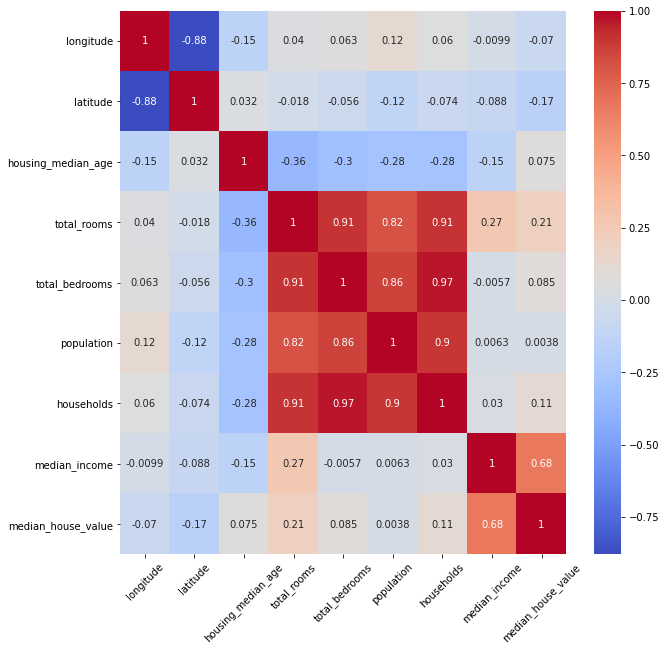

In [6]:
# Удаляем нечисловые столбцы
df_spark_double = df.drop('ocean_proximity')

# Преобразуем векторный столбец
vector_col = 'corr_features'
assembler = VectorAssembler(inputCols=df_spark_double.columns, outputCol=vector_col)
df_vector = assembler.transform(df_spark_double).select(vector_col)

# Получаем матрицу корреляции с помощью коэффициента Спирмена
matrix = Correlation.corr(df_vector, vector_col, method='spearman')

# Извлекаем значения корреляции
correlation_matrix = matrix.collect()[0]["spearman({})".format(vector_col)].values

# Преобразуем матрицу корреляции
correlation_matrix = correlation_matrix.reshape(len(df_spark_double.columns), len(df_spark_double.columns))

# Строим тепловую карту корреляции
fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', 
            xticklabels=df_spark_double.columns, 
            yticklabels=df_spark_double.columns)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

### Промежуточный вывод:

Проведён корреляционный анализ признаков.

По матрице корреляции присутствует сильная мультиколлинеарность параметров `longitude`, `latitude`, `total_rooms`, `total_bedrooms`, `households`.
Утечка данных отсутствует. Однако, видна весомая зависимость целевого параметра от признаков `median_income` и `ocean_proximity`.

## 4. Обучение моделей

### Первая модель

In [7]:
#median_house_value - это зависимая и предсказываемая переменная

stages = []

# Определяем этапы пайплайна
stages = []

# Категориальные колонки
cat_col = ['ocean_proximity']
for col in cat_col:
    string_indexer = StringIndexer(inputCol=col, outputCol=col + 'Index', handleInvalid='keep')
    encoder = OneHotEncoder(inputCols=[string_indexer.getOutputCol()], outputCols=[col + 'classVec'], dropLast=True)
    stages += [string_indexer, encoder]

# Числовые колонки
num_col = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
           'total_bedrooms', 'population', 'households', 'median_income']
assembler_num = VectorAssembler(inputCols=num_col, outputCol='num_features')
stages += [assembler_num]

# Стандартизация
scaler = StandardScaler(inputCol='num_features', outputCol='scaled_features', withStd=True, withMean=True)
stages += [scaler]

# Финальный сборщик
assembler_inputs = [c + "classVec" for c in cat_col] + ['scaled_features']
assembler_final = VectorAssembler(inputCols=assembler_inputs, outputCol='features')
stages += [assembler_final]

In [8]:
RANDOM_STATE = 42

#делим данные на обучающую и тестовую выборки
train_data, test_data = df.randomSplit([0.75, 0.25], seed=RANDOM_STATE)

#задаём модель линейной регрессии
lr = LinearRegression(featuresCol='features', labelCol='median_house_value', regParam=0.01)
stages += [lr]

# задаем план stages для обучения модели 
pipeline = Pipeline(stages=stages)

# тренируем модель
model = pipeline.fit(train_data)

# делаем предсказания на тестовой выборке
predictions = model.transform(test_data)

#сохраняем модель
pipeline.write().overwrite().save('model/linear_1_model')

25/08/11 11:30:22 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


In [9]:
# Проверяем размерность векторов
transformed_data = model.transform(train_data)
transformed_data.select(
    vector_to_array('ocean_proximityclassVec').alias('cat_features'),
    vector_to_array('scaled_features').alias('num_features'),
    vector_to_array('features').alias('final_features')
).selectExpr(
    'size(cat_features) as cat_feature_count',
    'size(num_features) as num_feature_count',
    'size(final_features) as final_feature_count'
).show()

+-----------------+-----------------+-------------------+
|cat_feature_count|num_feature_count|final_feature_count|
+-----------------+-----------------+-------------------+
|                5|                8|                 13|
|                5|                8|                 13|
|                5|                8|                 13|
|                5|                8|                 13|
|                5|                8|                 13|
|                5|                8|                 13|
|                5|                8|                 13|
|                5|                8|                 13|
|                5|                8|                 13|
|                5|                8|                 13|
|                5|                8|                 13|
|                5|                8|                 13|
|                5|                8|                 13|
|                5|                8|                 13|
|             

#### Метрики модели

In [10]:
# Оценка модели
evaluator = RegressionEvaluator(labelCol='median_house_value', predictionCol='prediction', metricName='rmse')
rmse = evaluator.evaluate(predictions)

evaluator.setMetricName('mae')
mae = evaluator.evaluate(predictions)

evaluator.setMetricName('r2')
r2 = evaluator.evaluate(predictions)

# Вывод результатов
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

df_pd_pred_1 = predictions.toPandas()

RMSE: 69712.04614207917
MAE: 50362.575232745236
R2: 0.6419467367053819


Метрики, полученные в результате работы модели, показывают на плохой результат. Косвенно можно сделать вывод, что модель переобучена.

#### Анализ остатков

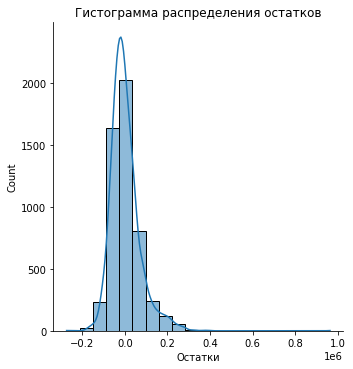

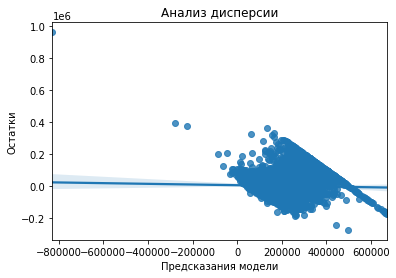

In [11]:
residuals = df_pd_pred_1['median_house_value'] - df_pd_pred_1['prediction']

sns.displot(residuals, kde=True, multiple='stack', bins=20)
plt.title('Гистограмма распределения остатков')
plt.xlabel('Остатки')
plt.show()

fig, ax = plt.subplots()
sns.regplot(x=df_pd_pred_1['prediction'], y=residuals, fit_reg=True)
plt.xlabel('Предсказания модели')
plt.ylabel('Остатки')
plt.title('Анализ дисперсии')
plt.show()

На гистограмме наблюдается симметричное распределение с несколькими выбросами.

Дисперсия остатков в основном постоянна.

Вывод: модель достаточно предсказуема, а её прогнозы в определённой степени надёжны.

#### Анализ важности признаков

Оценим важность признаков модели.

In [12]:
lr_model = model.stages[-1]
assembler_stage = model.stages[-2]

coefficients = lr_model.coefficients
feature_names = assembler_stage.getInputCols()

# Выводим названия признаков и соответствующие им коэффициенты
print('Названия признаков и соответствующие им коэффициенты:')
coefficients = model.stages[-1].coefficients
feature_names = assembler.getInputCols()
for feature, coefficient in zip(feature_names, coefficients):
    print(feature, ": ", coefficient)

Названия признаков и соответствующие им коэффициенты:
longitude :  12608.137879057736
latitude :  -27092.571701276822
housing_median_age :  17301.75067792579
total_rooms :  8422.765730503786
total_bedrooms :  162382.24735079348
population :  -53334.17245478272
households :  -54795.87681344806
median_income :  13288.30987179888
median_house_value :  -5825.675940743357


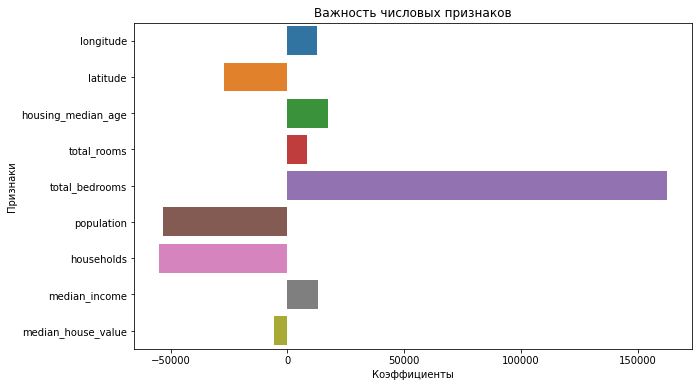

In [13]:
coefficients = model.stages[-1].coefficients[:len(feature_names)]  # Только коэффициенты для числовых признаков

# Создание DataFrame для seaborn
data = {'Features': feature_names, 'Coefficients': coefficients}
df_coef = pd.DataFrame(data)

# Создание графика
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficients', y='Features', data=df_coef)
plt.xlabel('Коэффициенты')
plt.ylabel('Признаки')
plt.title('Важность числовых признаков')
plt.show()

По графику видно, что наибольшее влияние оказывает параметр `total_bedrooms`.

### Вторая модель

In [14]:
df_2 = df.drop('ocean_proximity')

#median_house_value - это зависимая и предсказываемая переменная

stages = []

#преобразование численных колонок

num_col = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',\
               'total_bedrooms', 'population', 'households', 'median_income']

# собираем численные колонки в единый вектор
assembler = VectorAssembler(inputCols=num_col, outputCol='num_features')
stages += [assembler]

# создаем стандартизатор
scaler = StandardScaler(inputCol='num_features', outputCol='scaled_features', withStd=True, withMean=True)
stages += [scaler]

# Входные колонки для сборщика признаков
assembler_inputs = ['scaled_features']

# Преобразование нескольких колонок в вектор-колонку - признаки
assembler = VectorAssembler(inputCols=assembler_inputs, outputCol='features')
stages += [assembler]

In [15]:
#делим данные на обучающую и тестовую выборки
train_data_2, test_data_2 = df_2.randomSplit([0.75, 0.25], seed=RANDOM_STATE)

#задаём модель линейной регрессии
lr = LinearRegression(featuresCol='features', labelCol='median_house_value')
stages += [lr]

# задаем план stages для обучения модели 
pipeline_2 = Pipeline(stages=stages)

# тренируем модель
model_2 = pipeline_2.fit(train_data_2)

# делаем предсказания на тестовой выборке
predictions_2 = model_2.transform(test_data_2)

#сохраняем модель
pipeline_2.write().overwrite().save('model/linear_2_model')

25/08/11 11:31:07 WARN Instrumentation: [26ddcfe4] regParam is zero, which might cause numerical instability and overfitting.


#### Метрики модели

In [16]:
# Оценка модели
evaluator = RegressionEvaluator(labelCol='median_house_value', predictionCol='prediction', metricName='rmse')
rmse = evaluator.evaluate(predictions_2)

evaluator.setMetricName('mae')
mae = evaluator.evaluate(predictions_2)

evaluator.setMetricName('r2')
r2 = evaluator.evaluate(predictions_2)

# Вывод результатов
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

df_pd_pred_2 = predictions_2.toPandas()

RMSE: 70670.93999282991
MAE: 51272.26643612579
R2: 0.632028899259151


#### Анализ остатков

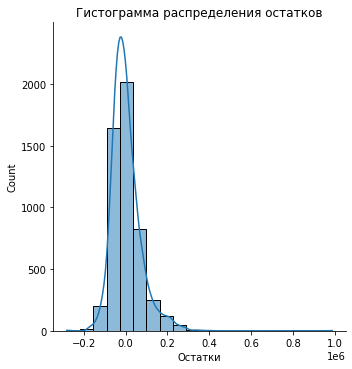

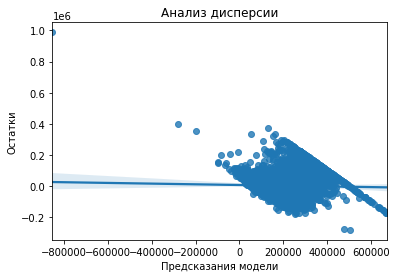

In [17]:
residuals = df_pd_pred_2['median_house_value'] - df_pd_pred_2['prediction']

sns.displot(residuals, kde=True, multiple='stack', bins=20)
plt.title('Гистограмма распределения остатков')
plt.xlabel('Остатки')
plt.show()

fig, ax = plt.subplots()
sns.regplot(x=df_pd_pred_2['prediction'], y=residuals, fit_reg=True)
plt.xlabel('Предсказания модели')
plt.ylabel('Остатки')
plt.title('Анализ дисперсии')
plt.show()

In [18]:
df_pd_pred = predictions.toPandas()
display(df_pd_pred)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,ocean_proximityIndex,ocean_proximityclassVec,num_features,scaled_features,features,prediction
0,-124.30,41.84,17.0,2677.0,531.0,1244.0,456.0,3.0313,103600.0,NEAR OCEAN,2.0,"(0.0, 0.0, 1.0, 0.0, 0.0)","[-124.3, 41.84, 17.0, 2677.0, 531.0, 1244.0, 4...","[-2.344583500765101, 2.8845654651862893, -0.92...","[0.0, 0.0, 1.0, 0.0, 0.0, -2.344583500765101, ...",149974.422696
1,-124.23,40.54,52.0,2694.0,453.0,1152.0,435.0,3.0806,106700.0,NEAR OCEAN,2.0,"(0.0, 0.0, 1.0, 0.0, 0.0)","[-124.23, 40.54, 52.0, 2694.0, 453.0, 1152.0, ...","[-2.3097502534238368, 2.278146334587757, 1.852...","[0.0, 0.0, 1.0, 0.0, 0.0, -2.3097502534238368,...",217668.760917
2,-124.23,41.75,11.0,3159.0,616.0,1343.0,479.0,2.4805,73200.0,NEAR OCEAN,2.0,"(0.0, 0.0, 1.0, 0.0, 0.0)","[-124.23, 41.75, 11.0, 3159.0, 616.0, 1343.0, ...","[-2.3097502534238368, 2.8425826022986973, -1.4...","[0.0, 0.0, 1.0, 0.0, 0.0, -2.3097502534238368,...",124520.522093
3,-124.22,41.73,28.0,3003.0,699.0,1530.0,653.0,1.7038,78300.0,NEAR OCEAN,2.0,"(0.0, 0.0, 1.0, 0.0, 0.0)","[-124.22, 41.73, 28.0, 3003.0, 699.0, 1530.0, ...","[-2.3047740752322246, 2.8332530772125644, -0.0...","[0.0, 0.0, 1.0, 0.0, 0.0, -2.3047740752322246,...",126292.445674
4,-124.19,40.73,21.0,5694.0,1056.0,2907.0,972.0,3.5363,90100.0,NEAR OCEAN,2.0,"(0.0, 0.0, 1.0, 0.0, 0.0)","[-124.19, 40.73, 21.0, 5694.0, 1056.0, 2907.0,...","[-2.2898455406573945, 2.366776822906003, -0.61...","[0.0, 0.0, 1.0, 0.0, 0.0, -2.2898455406573945,...",194418.278611
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5135,-114.60,33.62,16.0,3741.0,801.0,2434.0,824.0,2.6797,86500.0,INLAND,1.0,"(0.0, 1.0, 0.0, 0.0, 0.0)","[-114.6, 33.62, 16.0, 3741.0, 801.0, 2434.0, 8...","[2.482309345096316, -0.9498693452136501, -1.00...","[0.0, 1.0, 0.0, 0.0, 0.0, 2.482309345096316, -...",36948.609906
5136,-114.58,33.63,29.0,1387.0,236.0,671.0,239.0,3.3438,74000.0,INLAND,1.0,"(0.0, 1.0, 0.0, 0.0, 0.0)","[-114.58, 33.63, 29.0, 1387.0, 236.0, 671.0, 2...","[2.4922617014795336, -0.945204582670582, 0.024...","[0.0, 1.0, 0.0, 0.0, 0.0, 2.4922617014795336, ...",73647.695161
5137,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0,INLAND,1.0,"(0.0, 1.0, 0.0, 0.0, 0.0)","[-114.56, 33.69, 17.0, 720.0, 174.0, 333.0, 11...","[2.502214057862751, -0.9172160074121907, -0.92...","[0.0, 1.0, 0.0, 0.0, 0.0, 2.502214057862751, -...",-3534.307785
5138,-114.49,33.97,17.0,2809.0,635.0,83.0,45.0,1.6154,87500.0,INLAND,1.0,"(0.0, 1.0, 0.0, 0.0, 0.0)","[-114.49, 33.97, 17.0, 2809.0, 635.0, 83.0, 45...","[2.5370473052040223, -0.7866026562063528, -0.9...","[0.0, 1.0, 0.0, 0.0, 0.0, 2.5370473052040223, ...",13335.630933


### Третья модель - справочно, для экспериментов с фичами

In [19]:
df_3 = df.drop('longitude', 'latitude', 'median_income', 'ocean_proximity')

In [20]:
cat_col = 'ocean_proximity'
num_col = [ 'housing_median_age',\
           'total_rooms', 'households', 'total_bedrooms',  'population']
target = 'median_house_value'

#median_house_value - это зависимая и предсказываемая переменная

stages = []

#преобразование категориальных колонок

'''for col in cat_col:
    #преобразование категориальных колонок в бинарные вектора благодаря строковому преобразователю
    string_indexer = StringIndexer(inputCol = col,
                                  outputCol = col + 'Index',
                                  handleInvalid = 'keep')
    encoder = OneHotEncoder(inputCol=string_indexer.getOutputCol(),
                            outputCol=col + 'classVec', dropLast=True)
    stages += [string_indexer, encoder]'''

#преобразование численных колонок

# собираем численные колонки в единый вектор
assembler = VectorAssembler(inputCols=num_col, outputCol='num_features')
stages += [assembler]

# создаем стандартизатор
scaler = StandardScaler(inputCol='num_features', outputCol='scaled_features', withStd=True, withMean=True)
stages += [scaler]

# Входные колонки для сборщика признаков
assembler_inputs = ['scaled_features']

# Преобразование нескольких колонок в вектор-колонку - признаки
assembler = VectorAssembler(inputCols=assembler_inputs, outputCol='features')
stages += [assembler]

In [21]:
#делим данные на обучающую и тестовую выборки
train_data_3, test_data_3 = df_3.randomSplit([0.75, 0.25], seed=RANDOM_STATE)

#задаём модель линейной регрессии
lr = LinearRegression(featuresCol='features', labelCol=target, regParam=0.1)
stages += [lr]

# задаем план stages для обучения модели 
pipeline_3 = Pipeline(stages=stages)

# тренируем модель
model_3 = pipeline_3.fit(train_data_3)

# делаем предсказания на тестовой выборке
predictions_3 = model_3.transform(test_data_3)

#сохраняем модель
pipeline_3.write().overwrite().save('model/linear_3_model')

In [22]:
# Оценка модели
evaluator = RegressionEvaluator(labelCol=target, predictionCol='prediction', metricName='rmse')
rmse = evaluator.evaluate(predictions_3)

evaluator.setMetricName('mae')
mae = evaluator.evaluate(predictions_3)

evaluator.setMetricName('r2')
r2 = evaluator.evaluate(predictions_3)

# Вывод результатов
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

df_pd_pred_3 = predictions_3.toPandas()

# Остановка сессии

spark.stop()

RMSE: 105694.95079966342
MAE: 82682.93969572255
R2: 0.16306761508559708


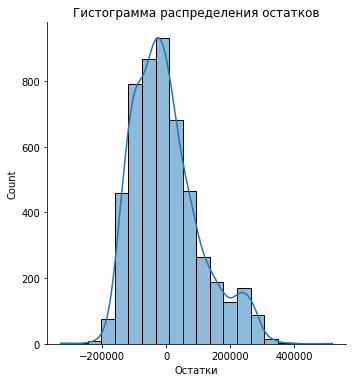

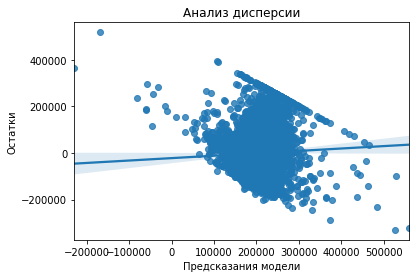

In [23]:
residuals = df_pd_pred_3[target] - df_pd_pred_3['prediction']

sns.displot(residuals, kde=True, multiple='stack', bins=20)
plt.title('Гистограмма распределения остатков')
plt.xlabel('Остатки')
plt.show()

fig, ax = plt.subplots()
sns.regplot(x=df_pd_pred_3['prediction'], y=residuals, fit_reg=True)
plt.xlabel('Предсказания модели')
plt.ylabel('Остатки')
plt.title('Анализ дисперсии')
plt.show()

### Промежуточный вывод:

После обучения моделей сравнены результаты работы линейной регрессии на двух наборах данных по метрикам RMSE, MAE и R2:

* RMSE: 69712.13
* MAE: 50362.59
* R2: 0.64

На гистограмме распределения остатков наблюдается симметричное распределение с несколькими выбросами.

Дисперсия остатков в основном постоянна.

Вывод: модель достаточно предсказуема, а её прогнозы в определённой степени надёжны.

Анализ важности признаков показал, что наибольшее влияние оказывает параметр `total_rooms`.

При удалении категориального признака метрики немного ухудшились:

* RMSE: 70670.94
* MAE: 51272.27
* R2: 0.63

Комбинации с различными параметрами (справочная модель) к улучшению метрик не привели. Необходима работа над фичами или создание других моделей.

# 5. Анализ результатов

В проекте нужно было обучить модель линейной регрессии на данных о жилье в Калифорнии в 1990 году. На основе данных нужно предсказать медианную стоимость дома в жилом массиве с помощью модели линейной регрессии. Для оценки качества модели нужно использовать метрики RMSE, MAE и R2.

В колонках датасета содержатся следующие данные:

    longitude — широта;
    latitude — долгота;
    housing_median_age — медианный возраст жителей жилого массива;
    total_rooms — общее количество комнат в домах жилого массива;
    total_bedrooms — общее количество спален в домах жилого массива;
    population — количество человек, которые проживают в жилом массиве;
    households — количество домовладений в жилом массиве;
    median_income — медианный доход жителей жилого массива;
    median_house_value — медианная стоимость дома в жилом массиве;
    ocean_proximity — близость к океану.
    
В ходе **исследовательского анализа данных** изучены параметры датафрейма. Проверены данные на наличие аномалий и выбросов. Построены гистограммы распределения категориального и количественных признаков. 

В столбцах `longitude` и `latitude` "хаотичное" распределение можно объяснить предположением, что определённые широта и долгота связаны с населёнными пунктами, где, соответственно, плотность застройки и количество домовладений гораздо выше, чем в сельской местности.

Наблюдаются множественные выбросы в столбце `housing_median_age`. Вероятно, это связано с демографическй ситуацией в определённые годы, оттоком моложёжи в другие штаты для каких-либо жизненных достижений (учёба в университете, работа). Пиковое значение около 50 лет можно объяснить тем фактом, что состоявшиеся в жизни люди к пенсии перебираются в более тёплый климат, в курортные зоны.

В столбцах `total_rooms`, `total_bedrooms`, `population`, `households`, `median_income` и `median_house_value` наюлюдаются нормальные распределения со смещением влево. Это связано с аномальными значениями: например, бОльшая комнатность и плотность населения в городской черте, высокоэтажной застройке. Стоимость жилья и доходы также подвержены влиянию сверхдорогих позиций и сверхбогатых жителей.

В столбце `ocean_proximity` категориальные значения корректны. Однако, стоит заметить что количество наблюдений в категории "ISLAND" ничтожно мало по сравнению с остальными категориями, что может потенциально привести к увеличению погрешности модели. **Также этот факт не похволит нам применить стратификацию при разбиении датасета для обучения моделей.**

В ходе **предобработки данных** заполнены пропуски в `total_bedrooms` медианными значениями. Неявные и полные дубликаты отсутствуют. В данном случае применение пайплайна нецелесообразно, т.к. предобработка минимальна и проста.

Проведён **корреляционный анализ** признаков в количественной шкале в итоговой таблице для моделирования. Присутствует сильная мультиколлинеарность параметров `longitude`, `latitude`, `total_rooms`, `total_bedrooms`, `households`. По матрице корреляции phik_matrix() утечка данных отсутствует. Однако, видна весомая зависимость целевого параметра от признаков `median_income` и `ocean_proximity`.

**Обучение моделей.** По заданию необходимо построить две модели линейной регрессии на разных наборах данных: 

* используя все данные из файла;
* используя только числовые переменные, исключив категориальные.

Для построения модели использован оценщик LinearRegression из библиотеки MLlib.

После обучения моделей сравнены результаты работы линейной регрессии на двух наборах данных по метрикам RMSE, MAE и R2:

* RMSE: 69712.13
* MAE: 50362.59
* R2: 0.64

На гистограмме распределения остатков наблюдается симметричное распределение с несколькими выбросами.

Дисперсия остатков в основном постоянна.

Вывод: модель достаточно предсказуема, а её прогнозы в определённой степени надёжны.

Анализ важности признаков показал, что наибольшее влияние оказывает параметр `total_rooms`.

При удалении категориального признака метрики немного ухудшились:

* RMSE: 70670.94
* MAE: 51272.27
* R2: 0.63



Комбинации с различными параметрами (справочная модель) к улучшению метрик не привели. Необходима работа над фичами или создание других моделей. Возможно, добавление новых параметров.